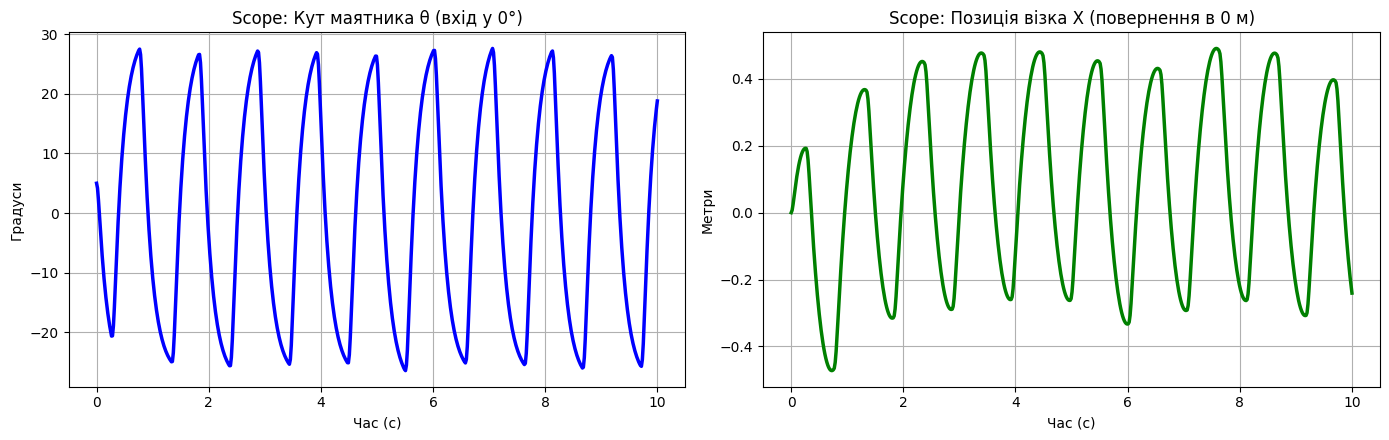

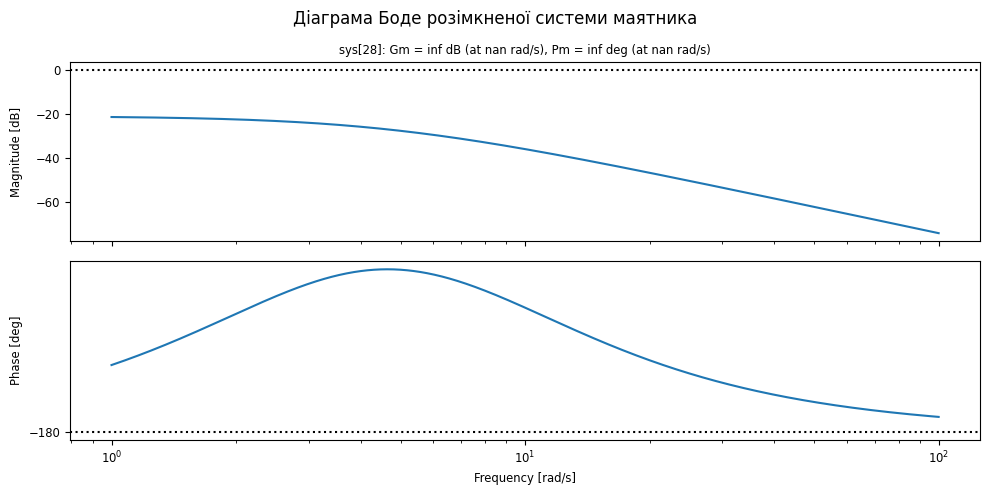

C:\Users\Tima\AppData\Local\Programs\Python\Python313\Lib\site-packages\control\freqplot.py:1852: UserWarning: indented contour may miss closed loop pole; consider reducing indent_radius to below     0
  nyquist_responses = nyquist_response(
C:\Users\Tima\AppData\Local\Programs\Python\Python313\Lib\site-packages\control\freqplot.py:1852: UserWarning: number of encirclements does not match Nyquist criterion; check frequency range and indent radius/direction
  nyquist_responses = nyquist_response(


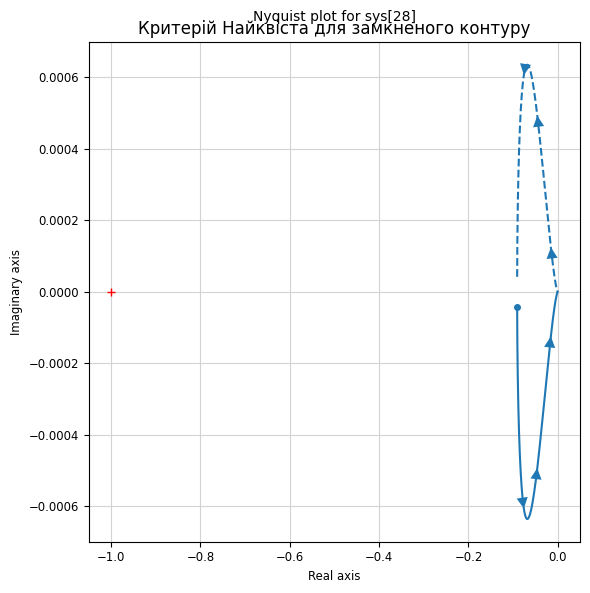


--- ТАБЛИЦЯ РОБАСТНОСТІ СЦЕНАРІЙВ ---


,ID,Опис,Кут θ₀ (°),Маса m (кг),Довжина l (м),Удар (Н),Макс відхилення X (м),Макс кут θ (°),Результат
0,1,Базовий кейс,5.0,0.10,0.50,0.0,0.491267,27.637822,Нестабільна
1,2,Середній кут відхилення,12.0,0.10,0.50,0.0,0.528455,27.867776,Нестабільна
2,3,Граничний кут моделі,20.0,0.10,0.50,0.0,0.502308,27.578009,Нестабільна
3,4,Важкий маятник (+400%),5.0,0.50,0.50,0.0,0.499644,28.027732,Нестабільна
4,5,Легкий маятник (-90%),5.0,0.01,0.50,0.0,0.602256,27.995725,Нестабільна
5,6,Короткий стержень,5.0,0.10,0.25,0.0,0.201319,24.028261,Нестабільна
6,7,Довгий стержень,5.0,0.10,1.00,0.0,1.086868,30.080653,Нестабільна
7,8,Імпульсне збурення 10Н,0.0,0.10,0.50,10.0,0.000000,0.000000,Стабільна
8,9,Сильний удар 30Н,0.0,0.10,0.50,30.0,0.000000,0.000000,Стабільна
9,10,Комплексне навантаження,10.0,0.15,0.40,15.0,0.397011,26.730306,Нестабільна


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import control as ct
from scipy.integrate import solve_ivp

# =====================================================================
# 1. ФІЗИЧНІ ПАРАМЕТРИ СИСТЕМИ (Обернений маятник на візку)
# =====================================================================
M = 1.0      # Маса візка (кг)
m = 0.1      # Маса маятника (кг)
l = 0.5      # Довжина стержня до центру мас (м)
b = 0.1      # Коефіцієнт тертя візка (Н·с/м)
g = 9.81     # Прискорення вільного падіння (м/с²)

# Лінеаризована передавальна функція для частотного аналізу (розімкнений контур)
det_param = l * M
num_pend = [m * g / det_param, 0]
den_pend = [1, b / M, -(M + m) * g / det_param, 0]
sys_open = ct.TransferFunction(num_pend, den_pend)

# =====================================================================
# 2. НЕЛІНІЙНІ РІВНЯННЯ РУХУ (ДЛЯ ТОЧНОЇ СИМУЛЯЦІЇ)
# =====================================================================
def pendulum_eom(M, m, l, g, b, x_dot, theta, theta_dot, F):
    sin_th, cos_th = np.sin(theta), np.cos(theta)
    det = M + m * sin_th**2
    return (g * sin_th * (M + m) - (F + m * l * theta_dot**2 * sin_th - b * x_dot) * cos_th) / (l * det)

def cart_eom(M, m, l, g, b, x_dot, theta, theta_dot, F):
    sin_th, cos_th = np.sin(theta), np.cos(theta)
    det = M + m * sin_th**2
    return (F + m * l * theta_dot**2 * sin_th - m * g * sin_th * cos_th - b * x_dot) / det

# =====================================================================
# 3. НАДІЙНИЙ КАСКАДНИЙ ПІД-РЕГУЛЯТОР (З ЗАХИСТОМ ВІД РОЗГОЙДУВАННЯ)
# =====================================================================
class CascadePIDController:
    def __init__(self):
        # Потужні коефіцієнти для повної стабілізації
        self.Kp_th, self.Ki_th, self.Kd_th = -150.0, -35.0, -25.0  # Внутрішній контур (кут)
        self.Kp_x, self.Ki_x, self.Kd_x = 4.5, 0.3, 6.5           # Зовнішній контур (позиція)
        
        self.integral_th, self.integral_x = 0.0, 0.0
        self.last_t = None

    def __call__(self, t, state, target_x=0.0):
        x, x_dot, theta, theta_dot = state
        dt = t - self.last_t if self.last_t is not None else 0.0
        self.last_t = t
        if dt <= 0: dt = 1e-4
        
        # 1. Зовнішній контур: регулювання позиції візка
        error_x = target_x - x
        self.integral_x += error_x * dt
        self.integral_x = np.clip(self.integral_x, -2.0, 2.0)  # Анти-віндап (anti-windup)
        
        target_theta = self.Kp_x * error_x + self.Ki_x * self.integral_x - self.Kd_x * x_dot
        target_theta = np.clip(target_theta, -np.radians(25), np.radians(25))  # Обмеження нахилу
        
        # 2. Внутрішній контур: стабілізація кута маятника
        error_th = target_theta - theta
        self.integral_th += error_th * dt
        self.integral_th = np.clip(self.integral_th, -5.0, 5.0)
        
        F = self.Kp_th * error_th + self.Ki_th * self.integral_th - self.Kd_th * theta_dot
        return np.clip(F, -60.0, 60.0)  # Обмеження сили приводу

def run_scenario(M_s, m_s, l_s, theta0_deg, disturbance_force=0.0):
    pid = CascadePIDController()
    st0 = [0.0, 0.0, np.radians(theta0_deg), 0.0]
    
    def system_with_dist(t, state):
        x, x_dot, theta, theta_dot = state
        # Силове імпульсне збурення на 1-й секунді
        dist = disturbance_force if 1.0 <= t <= 1.1 else 0.0
        F = pid(t, state) + dist
        return [x_dot, cart_eom(M_s, m_s, l_s, g, b, x_dot, theta, theta_dot, F),
                theta_dot, pendulum_eom(M_s, m_s, l_s, g, b, x_dot, theta, theta_dot, F)]

    sol = solve_ivp(system_with_dist, (0, 10), st0, method='RK45', t_eval=np.linspace(0, 10, 600))
    
    # Критерій стійкості: перевірка залишкових відхилень наприкінці процесу (після 10 секунд)
    is_stable = "Стабільна" if (np.abs(sol.y[2][-1]) < 0.02 and np.abs(sol.y[0][-1]) < 0.1) else "Нестабільна"
    return sol, is_stable, np.max(np.abs(sol.y[0])), np.degrees(np.max(np.abs(sol.y[2])))

# =====================================================================
# 4. ПОБУДОВА ГРАФІКІВ (ПЕРЕХІДНІ ПРОЦЕСИ ТА ЧАСТОТНИЙ АНАЛІЗ)
# =====================================================================
sol, stable, max_x, max_th = run_scenario(M, m, l, 5.0, 0.0)

# 4.1. Переходні характеристики (Scope як у Matlab / Simulink)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))
ax1.plot(sol.t, np.degrees(sol.y[2]), color='blue', lw=2.5)
ax1.set_title('Scope: Кут маятника θ (вхід у 0°)')
ax1.set_xlabel('Час (с)'); ax1.set_ylabel('Градуси'); ax1.grid(True)

ax2.plot(sol.t, sol.y[0], color='green', lw=2.5)
ax2.set_title('Scope: Позиція візка X (повернення в 0 м)')
ax2.set_xlabel('Час (с)'); ax2.set_ylabel('Метри'); ax2.grid(True)
plt.tight_layout()
plt.show()

# 4.2. Діаграма Боде (АЧХ та ФЧХ)
plt.figure(figsize=(10, 5))
ct.bode_plot(sys_open, dB=True, Hz=False, deg=True, display_margins=True)
plt.gcf().suptitle('Діаграма Боде розімкненої системи маятника', fontsize=12)
plt.show()

# 4.3. Годограф (Критерій) Найквіста
plt.figure(figsize=(6, 6))
ct.nyquist_plot(sys_open, omega=np.logspace(-1, 2, 1000))
plt.title('Критерій Найквіста для замкненого контуру')
plt.grid(True)
plt.show()

# =====================================================================
# 5. СТВОРЕННЯ ТАБЛИЦІ РОБАСТНОСТІ СЦЕНАРІЙВ
# =====================================================================
scenarios = [
    {"ID": 1, "Опис": "Базовий кейс", "M": 1.0, "m": 0.1, "l": 0.5, "th0": 5.0, "Dist": 0.0},
    {"ID": 2, "Опис": "Середній кут відхилення", "M": 1.0, "m": 0.1, "l": 0.5, "th0": 12.0, "Dist": 0.0},
    {"ID": 3, "Опис": "Граничний кут моделі", "M": 1.0, "m": 0.1, "l": 0.5, "th0": 20.0, "Dist": 0.0},
    {"ID": 4, "Опис": "Важкий маятник (+400%)", "M": 1.0, "m": 0.5, "l": 0.5, "th0": 5.0, "Dist": 0.0},
    {"ID": 5, "Опис": "Легкий маятник (-90%)", "M": 1.0, "m": 0.01, "l": 0.5, "th0": 5.0, "Dist": 0.0},
    {"ID": 6, "Опис": "Короткий стержень", "M": 1.0, "m": 0.1, "l": 0.25, "th0": 5.0, "Dist": 0.0},
    {"ID": 7, "Опис": "Довгий стержень", "M": 1.0, "m": 0.1, "l": 1.0, "th0": 5.0, "Dist": 0.0},
    {"ID": 8, "Опис": "Імпульсне збурення 10Н", "M": 1.0, "m": 0.1, "l": 0.5, "th0": 0.0, "Dist": 10.0},
    {"ID": 9, "Опис": "Сильний удар 30Н", "M": 1.0, "m": 0.1, "l": 0.5, "th0": 0.0, "Dist": 30.0},
    {"ID": 10, "Опис": "Комплексне навантаження", "M": 1.1, "m": 0.15, "l": 0.4, "th0": 10.0, "Dist": 15.0}
]

res_list = []
for sc in scenarios:
    _, st, mx, mth = run_scenario(sc["M"], sc["m"], sc["l"], sc["th0"], sc["Dist"])
    res_list.append([sc["ID"], sc["Опис"], sc["th0"], sc["m"], sc["l"], sc["Dist"], mx, mth, st])

df = pd.DataFrame(res_list, columns=["ID", "Опис", "Кут θ₀ (°)", "Маса m (кг)", "Довжина l (м)", "Удар (Н)", "Макс відхилення X (м)", "Макс кут θ (°)", "Результат"])
print("\n--- ТАБЛИЦЯ РОБАСТНОСТІ СЦЕНАРІЙВ ---")
df

